# 01 - Cloud Field Overview

Time–height pcolormesh of bulk droplet (NW) and ice-crystal (NF) number
concentrations for every meteogram station in the Zarr store.

Layout: **n_stations rows x 2 columns** (left = NW, right = NF).

### Zarr v2 / v3 compatibility notes

The Zarr stores are written with `zarr_format=2` to work around several
incompatibilities between `xarray` (≥ 2025.4) and `zarr-python` 3.x:

| Issue | Symptom | Resolution |
|-------|---------|------------|
| **Codec API mismatch** | `TypeError: Expected a BytesBytesCodec. Got <class 'numcodecs.blosc.Blosc'>` | Force `zarr_format=2` in `to_zarr()` so `numcodecs.Blosc` is accepted as `compressor`. |
| **Unicode string dtype** | `ValueError: No Zarr data type found that matches {'name': '<U14', 'object_codec_id': 'vlen-utf8'}` | Store string coordinates (e.g. `expname`) as fixed-length bytes (`dtype='S'`) instead of Unicode (`dtype='U'`). zarr-python 3.x infers a `vlen-utf8` codec for `<U` arrays but cannot read it back. |
| **Region writes on coords** | `ValueError: variables … must have at least one dimension in common with the region's dimensions` | Abandoned streaming region-writes; build the full dataset lazily, then write in a single pass. |
| **Fill-value round-trip** | `AttributeError: 'Float32' object has no attribute 'value'` on `open_dataset` | Caused by zarr v3 metadata on read; pinning `zarr_format=2` avoids the issue. |

Existing stores created with `<U` dtypes can be patched locally by converting
the `expname` chunk data from `<U14` → `|S14` and updating `.zarray` /
`.zmetadata` (see `docs/logbook.md`, entry 2026-03-04).


TODO:

- [x] add turbulence, vertical wind speed, temperature, humidity, supersaturation, and other meteorological variables as contour lines into the time-height plots
- [ ] optional: check if overlay variables correlate with number/mass concentrations or tendencies (see correlation cell below)



In [1]:
import sys
from pathlib import Path

src_dir = next(p / "src" for p in (Path.cwd(), *Path.cwd().parents)
               if (p / "src" / "polarcap_runtime.py").is_file())
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from polarcap_runtime import is_server
import platform, socket
print("system:", platform.system(), platform.release())
print("hostname:", socket.gethostname())
print("is_server:", is_server())

system: Darwin 25.3.0
hostname: MacBookPro
is_server: False


In [2]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib.gridspec as gs
import matplotlib.patches as mpatches

from xhistogram.xarray import histogram as xhist
from utilities import (
    get_extpar_data, create_new_jet3, create_fade_cmap, make_pastel, apply_publication_style
)

## Configuration

In [3]:

zarr_file = "Meteogram_cs-eriswil__20260304_110254_nVar136_nMet3_nExp5.zarr"
cs_run = "_".join(zarr_file.split("_")[1:5])

data_dir = Path.home() / "data" / "cosmo-specs" / "meteograms" / cs_run
extpar_path400 = Path.home() / "data" / "cosmo-specs" / "meteograms" / "extPar_Eriswil_50x40.nc"
extpar_path100 = Path.home() / "data" / "cosmo-specs" / "meteograms" / "extPar_Eriswil_200x160.nc"

# zarr_files = sorted(data_dir.glob(data_dir))
zarr_files = [data_dir / zarr_file]
print(f"Available Zarr stores in {data_dir}:")
for z in zarr_files:
    print(f"  {z.name}")

# pick the store to plot (edit index or path as needed)
zarr_path = zarr_files[-1]
print(f"\nUsing: {zarr_path.name}")
print(f"ExtPar: {extpar_path400.name}")
print(f"ExtPar: {extpar_path100.name}")

Available Zarr stores in /Users/schimmel/data/cosmo-specs/meteograms/cs-eriswil__20260304_110254:
  Meteogram_cs-eriswil__20260304_110254_nVar136_nMet3_nExp5.zarr

Using: Meteogram_cs-eriswil__20260304_110254_nVar136_nMet3_nExp5.zarr
ExtPar: extPar_Eriswil_50x40.nc
ExtPar: extPar_Eriswil_200x160.nc


In [4]:
LBB = slice(30, 50)   # liquid bin range
CBB = slice(30, 50)   # crystal bin range

# experiment index to plot
EXP_IDX = 1

jet = create_new_jet3()
paste_jet = make_pastel(jet, desaturation=0.25, darken=0.90)
soft_jet = create_fade_cmap(paste_jet, n_fade=2)

# {source_var: (output_name, bin_slice, pos_filter, unit_conversion, plot_label, plot_kwargs)}
active_vars = {
    "NW": ("NW_bulk", LBB, True, True,  "NW – droplet", dict(norm=None, vmin=1, vmax=600, cmap='coolwarm')),
    "NF": ("NF_bulk", CBB, True, True,  "NF – ice crystal", dict(norm=None, vmin=1e-8, vmax=10, cmap='coolwarm')),
    "SUM_CONDN": ("SUM_CONDN_bulk", LBB, False, True, "CONDN – condensation", 
                  dict(norm=mcolors.SymLogNorm(linthresh=1e-4, linscale=0.01), cmap='coolwarm')),
    "SUM_KOLLNI": ("SUM_KOLLNI_bulk", CBB, False, True, "KOLLNI – collision",  
                   dict(norm=mcolors.SymLogNorm(linthresh=1e-12, linscale=0.01), cmap='coolwarm')),
    "SUM_IMMERN": ("SUM_IMMERN_bulk", CBB, False, True, "IMMERN – immers. frz", 
                   dict(norm=mcolors.SymLogNorm(linthresh=1e-12, linscale=0.01), cmap='coolwarm')),
    "T": ("T_bulk", None, False, False, "T – temperature", dict(vmin=-10, vmax=0, cmap='coolwarm')),
    "W": ("W_bulk", None, False, False, "W – vertical wind", dict(vmin=-0.5, vmax=0.5, cmap='coolwarm')),
    # ("SUM_KOLLNFROD", "SUM_KOLLNFROD", CBB, False, "KOLLNFROD – coll-coal",  dict(norm=mcolors.SymLogNorm(linthresh=1e-12, linscale=0.01), cmap='coolwarm')),
}


## Load data

In [5]:
ds_zarr = xr.open_dataset(zarr_path, engine="zarr")
print("Sizes:", dict(ds_zarr.sizes))
print("Data vars:", list(ds_zarr.data_vars))

assert "NW" in ds_zarr.data_vars and "NF" in ds_zarr.data_vars, (
    f"Zarr store must contain NW and NF. Found: {list(ds_zarr.data_vars)}"
)

Sizes: {'expname': 5, 'station': 3, 'time': 4033, 'height_level': 20, 'bins': 66, 'height_level2': 21, 'bins_boundaries': 67}
Data vars: ['SUM_CONDNFROD', 'SUM_P_kollqwf', 'SUM_P_BREAN', 'SUM_P_dqfmelt', 'PML', 'SUM_N_deponf', 'SUM_HOMN', 'SUM_kqf', 'NW', 'QV', 'SUM_P_KOLLQFROD', 'SUM_IMMERN', 'SUM_P_dqwmelt', 'SUM_dqfwmelt', 'SUM_N_IMMERN', 'SUM_CONDQWFROD', 'SUM_P_dnfmelt', 'SUM_N_KOLLQFROD_INS', 'SUM_dnwmelt', 'NINP', 'QFS', 'SUM_depoqf', 'SUM_P_deponf', 'SUM_N_kollqwf', 'SUM_N_CONDQFROD', 'QF', 'SUM_CONDQFROD', 'QIA', 'SUM_N_dqfwmelt', 'SUM_N_KOLLNFROD', 'SUM_P_KOLLNFROD_INS', 'SUM_P_KOLLNI', 'SUM_P_CONDQFROD', 'RHO', 'RGRENZ_right', 'SUM_P_KOLLQFROD_INS', 'SUM_dnfmelt', 'SUM_N_KOLLQFROD', 'SUM_CONDN', 'SUM_KOLLNFROD', 'SUM_N_dqffrier', 'PHL', 'SUM_P_dqfwmelt', 'SUM_N_CONDNFROD', 'QWS', 'SUM_P_HOMQ', 'QFA', 'SUM_P_dqffrier', 'SUM_N_KOLLQI', 'SUM_P_kqf', 'SUM_N_HOMN', 'SUM_BREAQ', 'SUM_N_kqwf', 'SUM_N_BREAN', 'SUM_N_KOLLNFRODI', 'SUM_N_CONDN', 'SUM_deponf', 'SUM_kollqwf', 'SUM_P_KOL

In [8]:
ds_exp = ds_zarr.isel(expname=EXP_IDX)
ds_exp = ds_exp.sel(time=slice(np.datetime64("2023-01-25T12:30:00"), np.datetime64("2023-01-25T13:10:00")))
# ds_exp = ds_exp.isel(height_level=slice(None, None, -1), height_level2=slice(None, None, -1))
rho = ds_exp["RHO"] if "RHO" in ds_exp.data_vars else None

print(f"Active variables: {[v for v in active_vars]}")
unit = r"cm$^{-3}$" if rho is not None else r"kg$^{-1}$"

# compute bulk fields for every entry in active_vars
bulk = {}
for src_name, (out_name, bin_sl, pos_only, uc, lbl, nkw) in active_vars.items():
    data = ds_exp[src_name]
    if 'bins' in data.sizes.keys():
        data = data.isel(bins=bin_sl).sum(dim="bins")
    if pos_only: 
        data = xr.where(data > 0, data, np.nan)
    if rho is not None and uc and src_name in ["NW", "NF"]:
        data = data * rho * 1e-6
    if src_name == "QV": 
        data = data * 1000.0  # kg/kg -> g/kg for contour labels
    if src_name == "T": 
        data = data - 273.15  # K -> °C for contour labels
        
    bulk[out_name] = data

bulk = xr.Dataset(bulk)
n_stations = ds_exp.sizes["station"]

# decode bytes→str if expname was stored as fixed-length bytes (zarr v3 compat)
exp_label = ds_zarr.expname.values[EXP_IDX]
# exp_label = _exp_label.decode() if isinstance(_exp_label, bytes) else str(_exp_label)
ST, SH = ds_zarr.time.size//20, 3  # quiver subsample (time, height)
slice_quiver = dict(time=slice(None, None, ST), height_level2=slice(None, None, SH))


# compute vertical wind fields for plotting dW from W_bulk
W = bulk["W_bulk"].isel(**slice_quiver).copy()
dW = W.diff("time")
wind = xr.Dataset({"dW": dW, "W": W})


print(f"Experiment: {exp_label}")
print(f"Stations: {n_stations}, variables: {len(active_vars)}")
print(f"Savety check if wind is ok : {wind.sizes},  {wind.data_vars}")



Active variables: ['NW', 'NF', 'SUM_CONDN', 'SUM_KOLLNI', 'SUM_IMMERN', 'T', 'W']
Experiment: b'20260304110638'
Stations: 3, variables: 7
Savety check if wind is ok : Frozen({'time': 12, 'station': 3, 'height_level2': 7}),  Data variables:
    dW       (station, time, height_level2) float32 1kB nan nan ... 0.00334
    W        (station, time, height_level2) float32 1kB ...


In [9]:
lat2D4, lon2D4, hsurf4 = get_extpar_data(str(extpar_path400))
lat2D1, lon2D1, hsurf1 = get_extpar_data(str(extpar_path100))
print(f"ExtPar grid 400m: {lat2D4.shape}, height range: {hsurf4.min():.0f}–{hsurf4.max():.0f} m")
print(f"ExtPar grid 100m: {lat2D1.shape}, height range: {hsurf1.min():.0f}–{hsurf1.max():.0f} m")

ExtPar grid 400m: (26, 36), height range: 597–1205 m
ExtPar grid 100m: (146, 186), height range: 523–1402 m


## Quicklook: time–height cross-sections

### Optional: correlation of T, W with NW/NF

Flatten time×height per station and compute Pearson correlation between bulk T and W and bulk number concentrations (NW_bulk, NF_bulk). Helps check if e.g. updrafts or temperature co-vary with droplet/ice number.

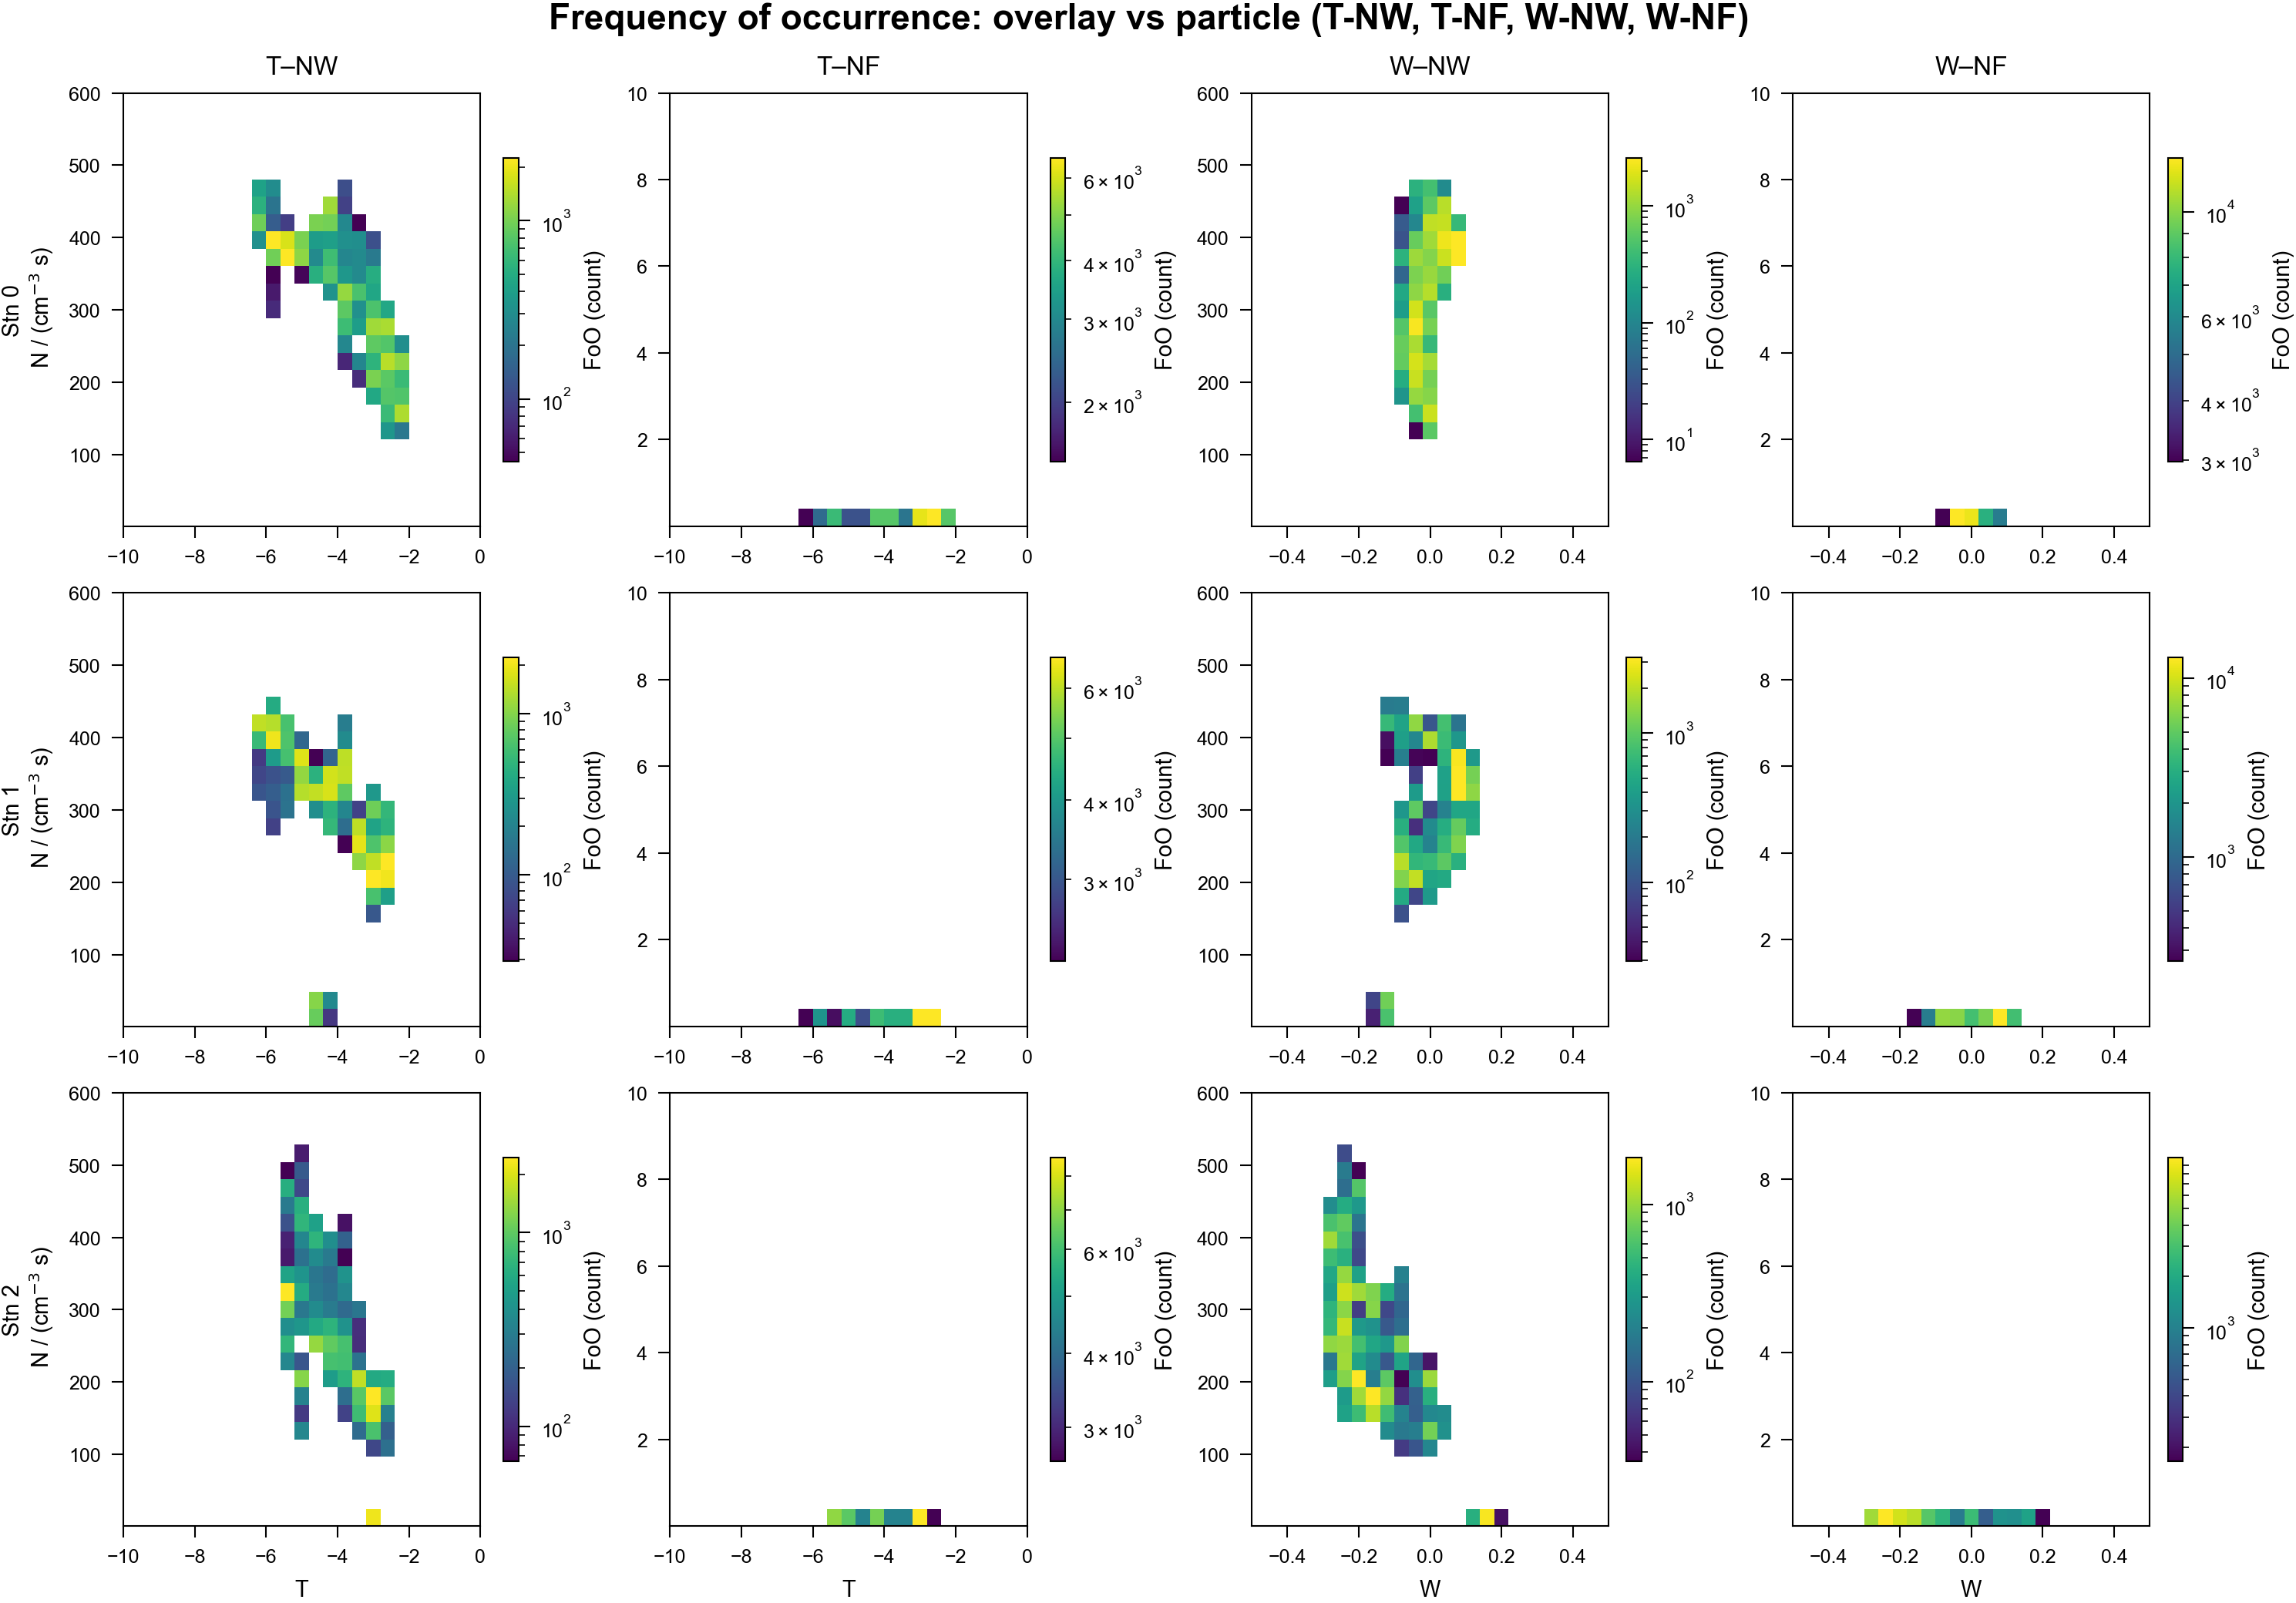

Correlation of T, W with NW_bulk, NF_bulk (flatten time×height per station)
Station 0:   T vs NW r = -0.83   |   T vs NF r =  0.54
Station 0:   W vs NW r =  0.59   |   W vs NF r = -0.35
Station 1:   T vs NW r = -0.66   |   T vs NF r =  0.64
Station 1:   W vs NW r =  0.40   |   W vs NF r = -0.08
Station 2:   T vs NW r = -0.61   |   T vs NF r =  0.03
Station 2:   W vs NW r = -0.78   |   W vs NF r = -0.53


In [10]:
apply_publication_style()
# Frequency of occurrence: 3×4 (stations × T-NW, T-NF, W-NW, W-NF). Bin edges from active_vars.
# active_vars = {source_var: (output_name, bin_slice, pos_filter, unit_conversion, plot_label, plot_kwargs)}
n_bins = 25
y_edges = {}
for vname in ["NW", "NF"]:
    _, _, _, _, _, nkw = active_vars[vname]
    vmin, vmax = nkw.get("vmin"), nkw.get("vmax")
    if vmin is not None and vmax is not None:
        y_edges[vname] = np.linspace(vmin, vmax, n_bins + 1)
x_edges = {}
for vname in ["T", "W"]:
    _, _, _, _, _, nkw = active_vars[vname]
    vmin, vmax = nkw.get("vmin"), nkw.get("vmax")
    if nkw.get("norm") is not None and hasattr(nkw.get("norm"), "vmin"):
        vmin, vmax = nkw["norm"].vmin, nkw["norm"].vmax
    if vmin is not None and vmax is not None:
        x_edges[vname] = np.linspace(vmin, vmax, n_bins + 1)

# Correlation of T_bulk, W_bulk with NW_bulk, NF_bulk (flatten time×height per station); FoO histograms.
if "NW_bulk" in bulk and "NF_bulk" in bulk and "T_bulk" in bulk and "W_bulk" in bulk:
    corr_list = []
    fig_foo, axes_foo = plt.subplots(3, 4, figsize=(10, 7), constrained_layout=True)
    # Align (time, height) so each ravel index is the same (time, height) for all vars
    def _time_dim(da):
        return "time" if "time" in da.dims else None
    def _height_dim(da):
        return "height_level" if "height_level" in da.dims else "height_level2"
    def _subset_ravel(da, n_time, n_h):
        tdim, hdim = _time_dim(da), _height_dim(da)
        out = da.isel({hdim: slice(0, n_h)})
        if tdim is not None:
            out = out.isel({tdim: slice(0, n_time)})
        return out.values.ravel()

    for st in range(n_stations):
        ds = bulk.isel(station=st)
        nw_s = ds["NW_bulk"]
        nf_s = ds["NF_bulk"]
        T_s = ds["T_bulk"]
        W_s = ds["W_bulk"]
        n_time = min(
            nw_s.sizes.get("time", nw_s.size),
            nf_s.sizes.get("time", nf_s.size),
            T_s.sizes.get("time", T_s.size),
            W_s.sizes.get("time", W_s.size),
        )
        n_h = min(
            nw_s.sizes.get(_height_dim(nw_s), 1),
            nf_s.sizes.get(_height_dim(nf_s), 1),
            T_s.sizes.get(_height_dim(T_s), 1),
            W_s.sizes.get(_height_dim(W_s), 1),
        )
        nw = _subset_ravel(nw_s, n_time, n_h)
        nf = _subset_ravel(nf_s, n_time, n_h)
        T = _subset_ravel(T_s, n_time, n_h)
        W = _subset_ravel(W_s, n_time, n_h)
        cols = [np.maximum(nw, 0), np.maximum(nf, 1e-6), T, W]
        names = ["NW", "NF", "T", "W"]
        mat = np.column_stack([c.astype(float) for c in cols])
        valid = np.isfinite(mat).all(axis=1)
        if valid.sum() >= 10:
            R = np.corrcoef(mat[valid].T)
            for j, name in enumerate(names):
                if j >= 2:
                    corr_list.append((st, name, "NW", R[j, 0], "NF", R[j, 1]))
        nw_da = xr.DataArray(nw, dims=["point"], attrs={"units": "cm$^{-3}$"}); nw_da.name = "NW"
        nf_da = xr.DataArray(nf, dims=["point"], attrs={"units": "cm$^{-3}$"}); nf_da.name = "NF"
        T_da  = xr.DataArray(T, dims=["point"], attrs={"units": "°C"});         T_da.name  = "T"
        W_da  = xr.DataArray(W, dims=["point"], attrs={"units": "m s$^{-1}$"}); W_da.name  = "W"
        n_size = nw_da.size
        for col, (x_da, y_da) in enumerate([(T_da, nw_da), (T_da, nf_da), (W_da, nw_da), (W_da, nf_da)]):
            x_bins = x_edges.get(x_da.name)
            y_bins = y_edges.get(y_da.name)
            if x_bins is None or y_bins is None:
                print(f"No bins for {x_da.name}–{y_da.name}")
                continue
            foo_da = xhist(x_da, y_da, bins=[x_bins, y_bins], dim=["point"])
            ax = axes_foo[st, col]
            foo_da = xr.where(foo_da > 0, foo_da, np.nan)
            if np.isfinite(foo_da).sum() == 0:
                print(f"No valid data for {x_da.name}–{y_da.name} at station {st}")
                continue
            dims = list(foo_da.dims)
            pc = foo_da.plot.pcolormesh(ax=ax, x=dims[0], y=dims[1], cmap="viridis", add_labels=False,
                add_colorbar=False, norm=mcolors.LogNorm(), robust=True)
            if col == 0:
                ax.set_ylabel(f"Stn {st}\n " + r"N / (cm$^{-3}$ s)")
            if st == 0:
                ax.set_title(f"{x_da.name}–{y_da.name}")
            if st == 2:
                ax.set_xlabel(x_da.name)
            fig_foo.colorbar(pc, ax=ax, label="FoO (count)", shrink=0.7)
    fig_foo.suptitle("Frequency of occurrence: overlay vs particle (T-NW, T-NF, W-NW, W-NF)", fontsize=11, fontweight="bold")
    plt.show()
    if corr_list:
        print("Correlation of T, W with NW_bulk, NF_bulk (flatten time×height per station)")
        for st, ov, _, r_nw, _, r_nf in corr_list:
            print(f"Station {st}:   {ov} vs NW r = {r_nw:>5.2f}   |   {ov} vs NF r = {r_nf:>5.2f}")
    else:
        print("No valid station pairs for correlation.")
else:
    print("NW_bulk, NF_bulk, T_bulk or W_bulk missing in bulk; skip correlation.")

/var/folders/g1/3_czjq2s0ms47mpj5clrshbr0000gp/T/ipykernel_51331/3107688597.py:83: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.savefig(f"meteograms_{exp_label}.png", dpi=300, bbox_inches="tight")


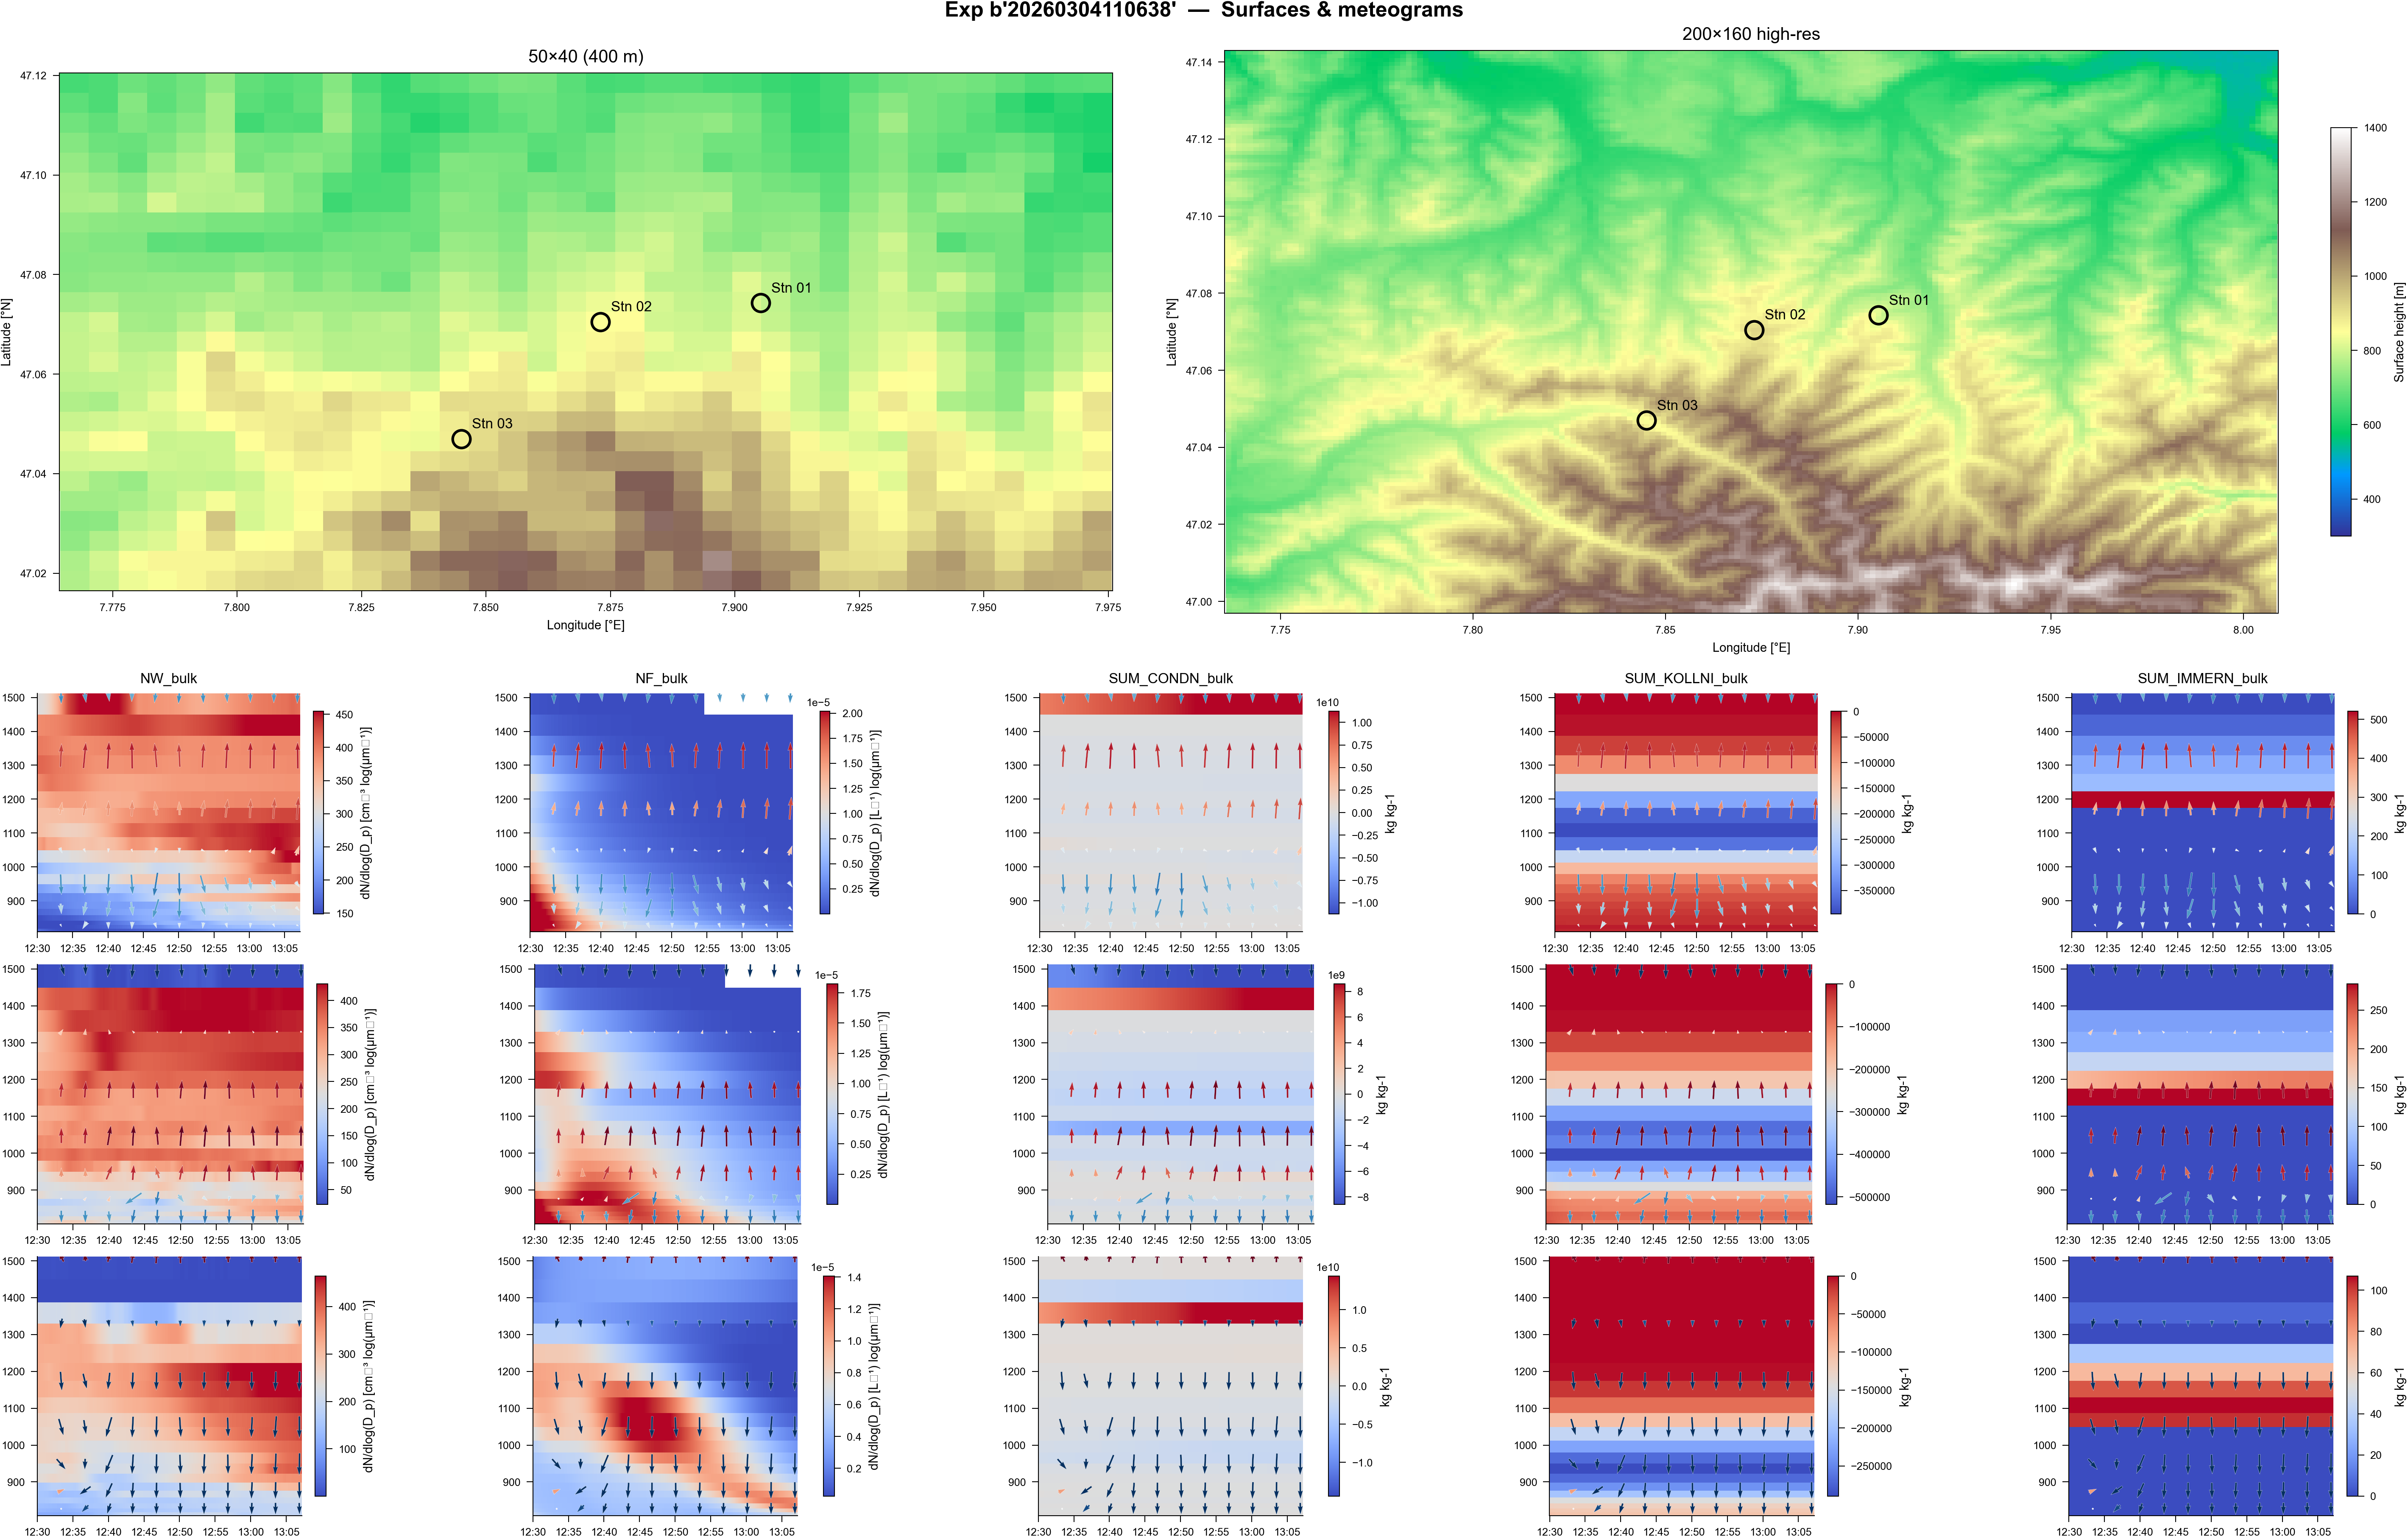

In [20]:
# Combined figure: GridSpec 8 cols × 5 rows

fig = plt.figure(figsize=(19, 12), constrained_layout=True)
grid = gs.GridSpec(5, 8, figure=fig,  hspace=0.05, wspace=0.15)

# ── Row 0–1: two surface height maps ──
ax_surf_50x40 = fig.add_subplot(grid[0:2, 0:4])
pm1 = ax_surf_50x40.pcolormesh(lon2D4, lat2D4, hsurf4, cmap="terrain", vmin=300, vmax=1400,shading="auto")
ax_surf_50x40.set_title("50×40 (400 m)", fontsize=10)
for i in range(n_stations):
    slat, slon = float(ds_exp.station_lat.values[i]), float(ds_exp.station_lon.values[i])
    sid = int(ds_exp.station.values[i])
    ax_surf_50x40.plot(slon, slat, "o", ms=10, mfc="none", mec="k", mew=1.5, zorder=5)
    ax_surf_50x40.annotate(f"Stn {sid:02d}", (slon, slat), textcoords="offset points", xytext=(6, 6), fontsize=8)
ax_surf_50x40.set_xlabel("Longitude [°E]")
ax_surf_50x40.set_ylabel("Latitude [°N]")
ax_surf_50x40.set_aspect("equal")

ax_surf_200x160 = fig.add_subplot(grid[0:2, 4:8])
pm2 = ax_surf_200x160.pcolormesh(lon2D1, lat2D1, hsurf1, cmap="terrain", vmin=300, vmax=1400,  shading="auto")
fig.colorbar(pm2, ax=ax_surf_200x160, label="Surface height [m]", orientation="vertical", shrink=0.7, pad=0.05)
ax_surf_200x160.set_title("200×160 high-res", fontsize=10)
for i in range(n_stations):
    slat, slon = float(ds_exp.station_lat.values[i]), float(ds_exp.station_lon.values[i])
    sid = int(ds_exp.station.values[i])
    ax_surf_200x160.plot(slon, slat, "o", ms=10, mfc="none", mec="k", mew=1.5, zorder=5)
    ax_surf_200x160.annotate(f"Stn {sid:02d}", (slon, slat), textcoords="offset points", xytext=(6, 6), fontsize=8)
ax_surf_200x160.set_xlabel("Longitude [°E]")
ax_surf_200x160.set_ylabel("Latitude [°N]")
ax_surf_200x160.set_aspect("equal")



# ── Rows 2–4: meteograms. T_bulk and W_bulk as overlays (T contours, W quivers). Use xarray plot API. ──
plot_vars = [k for k in bulk if k not in ("T_bulk", "W_bulk")]
n_vars = len(plot_vars)

axes_rows = []

for row_idx, i in enumerate(range(n_stations)):
    sid = int(ds_exp.station.values[i])
    sub = grid[2 + row_idx, :].subgridspec(1, n_vars, wspace=0.25)
    axes_row = [fig.add_subplot(sub[0, j]) for j in range(n_vars)]

    for idx, vname in enumerate(plot_vars):
        ax = axes_row[idx]
        ds = bulk.isel(station=i)
        da = ds[vname]
        cmap = 'cividis_r' if vname in ["NW", "NF"] else 'coolwarm'
        
        # pcolormesh variable
        pcm = da.plot.pcolormesh(ax=ax, x="time", y="HMLd", cmap=cmap, robust=True, add_colorbar=False, add_labels=False)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        for spine in ("top", "right"):
            ax.spines[spine].set_visible(False)
        fig.colorbar(pcm, ax=ax, label=da.attrs.get("units", ""), shrink=0.85)

        # temp contour
        cs = ds["T_bulk"].plot.contour(ax=ax, x="time", levels=np.linspace(-10, 0, 11), 
                                colors="black",  linewidths=0.5, alpha=0.75, add_labels=False,)
        ax.clabel(cs, cs.levels, inline=True, fontsize=6, fmt="%.0f")
        
        # wind quiver
        quiver_kwargs = dict( cmap="RdBu_r", vmin=-0.1, vmax=0.1,  alpha=1, edgecolor="white", linewidth=0.1, cbar_ax=None, add_guide=False, zorder=100) # scale=0.05,
        q = wind.isel(station=i).plot.quiver( ax=ax, y="HHLd", x="time", u="dW", v="W", hue="W", **quiver_kwargs
        )
        if q.colorbar is not None:
            q.colorbar.remove()

            
    axes_row[0].set_ylabel(f"Stn {sid:02d}", fontsize=9)
    axes_rows.append(axes_row)

axes_rows = np.array(axes_rows)
for row in axes_rows:
    for ax in row:
        ax.set(title="", xlabel="", ylabel="")
        # ax.invert_yaxis()
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
for ax, vname in zip(axes_rows[0], plot_vars):
    ax.set_title(vname)
fig.suptitle(f"Exp {exp_label}  —  Surfaces & meteograms", fontsize=12, fontweight="bold", y=1.01)
fig.savefig(f"meteograms_{exp_label}.png", dpi=300, bbox_inches="tight")
plt.show()